<a href="https://colab.research.google.com/github/gd-Sahat/ClockBiasPINN/blob/main/model_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import tensorflow as tf

# Print every op and the device it runs on:
tf.debugging.set_log_device_placement(True)

# Make sure we only grow into GPU memory, not grab it all at once:
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices('GPU'))

Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Input, Model, layers, optimizers
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from numpy.lib.stride_tricks import sliding_window_view

In [4]:
clkbias_diff = pd.read_csv('/content/drive/MyDrive/CLOCKBIASPINN/clkbias_diff.gz', compression='gzip')
clkbias_diff.head()

,id,timestamp,bias_interp_s,bias_s,bias_diff,bias_interp_ns,bias_ns,bias_diff_ns
0,G01,2023-05-01 00:00:00,0.000189,0.000189,-2.555663e-09,188869.424164,188866.868501,-2.555663
1,G01,2023-05-01 00:00:30,0.000189,0.000189,-2.543851e-09,188869.332078,188866.788226,-2.543851
2,G01,2023-05-01 00:01:00,0.000189,0.000189,-2.534747e-09,188869.239991,188866.705245,-2.534747
3,G01,2023-05-01 00:01:30,0.000189,0.000189,-2.547661e-09,188869.147905,188866.600244,-2.547661
4,G01,2023-05-01 00:02:00,0.000189,0.000189,-2.551347e-09,188869.055819,188866.504471,-2.551347


In [5]:
df = clkbias_diff.copy()

# 3.0 Ensure timestamp is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['id_enc'] = pd.factorize(df['id'])[0]

# Normalize bias_interp_ns
scaler_x = StandardScaler()
df['bias_interp_ns_norm'] = scaler_x.fit_transform(df[['bias_interp_ns']])

# Normalize time_s
t0 = df['timestamp'].min()
time_s = (df['timestamp'] - t0).dt.total_seconds().values.reshape(-1,1)
scaler_t = StandardScaler()
df['time_s_norm'] = scaler_t.fit_transform(time_s).astype(np.float32)

# Scale target
y_scaler = StandardScaler()
df['bias_diff_ns_scaled'] = y_scaler.fit_transform(
    df['bias_diff_ns'].values.reshape(-1,1)
).ravel().astype(np.float32)

In [6]:
# Colab Cell 5 – True temporal split + non-overlapping windows

from numpy.lib.stride_tricks import sliding_window_view

SEQ_LEN = 32
# 1) Split the raw DataFrame into three time-contiguous segments
train_end = df['timestamp'].quantile(0.8)
val_end   = df['timestamp'].quantile(0.9)

train_df = df[ df['timestamp'] <= train_end ].reset_index(drop=True)
val_df   = df[(df['timestamp'] > train_end) & (df['timestamp'] <= val_end)].reset_index(drop=True)
test_df  = df[ df['timestamp'] >  val_end ].reset_index(drop=True)

# 2) A helper to build windows inside a single segment
def make_windows(seg_df):
    FEAT   = seg_df[['id_enc','time_s_norm','bias_interp_ns_norm']].values.astype(np.float32)
    TARGET = seg_df['bias_diff_ns_scaled'].values.astype(np.float32)
    W = sliding_window_view(FEAT, window_shape=SEQ_LEN, axis=0)[:-1]
    Xs = W.transpose(0,2,1)             # shape: (num_windows, SEQ_LEN, 3)
    ys = TARGET[SEQ_LEN:]               # shape: (num_windows,)
    return Xs, ys

# 3) Build non-overlapping windows for each split
X_train, y_train = make_windows(train_df)
X_val,   y_val   = make_windows(val_df)
X_test,  y_test  = make_windows(test_df)

# 4) Quick sanity‐check sizes
print(f"Train windows: {X_train.shape} → {y_train.shape}")
print(f" Val  windows: {X_val.shape}   → {y_val.shape}")
print(f" Test windows: {X_test.shape}  → {y_test.shape}")


Train windows: (52823754, 32, 3) → (52823754,)
 Val  windows: (6602949, 32, 3)   → (6602949,)
 Test windows: (6602917, 32, 3)  → (6602917,)


In [ ]:
'''# Colab cell 4 (memory-efficient sliding windows)
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

SEQ_LEN = 32

from numpy.lib.stride_tricks import sliding_window_view

all_windows = sliding_window_view(features, window_shape=SEQ_LEN, axis=0)[:-1]
X = all_windows.transpose(0,2,1)           # (N-SEQ_LEN, 32, 3)
y = targets_scaled[SEQ_LEN:]               # (N-SEQ_LEN,)

# train/val split
split   = int(0.8 * len(X))
X_train = X[:split]
y_train = y[:split]
X_val   = X[split:]
y_val   = y[split:]'''


In [ ]:
# At the top of your notebook, once per session:
from google.colab import drive
drive.mount('/content/drive')

# …after Cell 3/4, once you have X_train, y_train, X_val, y_val:


np.save('/content/drive/MyDrive/CLOCKBIASPINN/X_train.npy', X_train)
np.save('/content/drive/MyDrive/CLOCKBIASPINN/y_train.npy', y_train)
np.save('/content/drive/MyDrive/CLOCKBIASPINN/X_val.npy',   X_val)
np.save('/content/drive/MyDrive/CLOCKBIASPINN/y_val.npy',   y_val)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X_train = np.load('/content/drive/MyDrive/CLOCKBIASPINN/X_train.npy')
y_train = np.load('/content/drive/MyDrive/CLOCKBIASPINN/y_train.npy')
X_val   = np.load('/content/drive/MyDrive/CLOCKBIASPINN/X_val.npy')
y_val   = np.load('/content/drive/MyDrive/CLOCKBIASPINN/y_val.npy')


In [ ]:
# Colab Cell 4: Define Custom Layers & Model
class PositionalEmbedding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len; self.d_model = d_model
        self.proj    = layers.Dense(d_model)
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)
    def call(self, x):
        x = self.proj(x)
        pos = tf.range(self.seq_len)[tf.newaxis, :]
        return x + self.pos_emb(pos)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_len":self.seq_len, "d_model":self.d_model})
        return cfg

class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att   = layers.MultiHeadAttention(num_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
    layers.Dense(ff_dim,
                 activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dense(d_model,
                 kernel_regularizer=regularizers.l2(1e-4)),
])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(rate)
        self.drop2 = layers.Dropout(rate)
        self.d_model, self.num_heads, self.ff_dim, self.rate = (
            d_model, num_heads, ff_dim, rate
        )
    def call(self, x, training=None):
        a = self.att(x, x)
        a = self.drop1(a, training=training)
        o1 = self.norm1(x + a)
        f = self.ffn(o1)
        f = self.drop2(f, training=training)
        return self.norm2(o1 + f)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({
          "d_model": self.d_model,
          "num_heads": self.num_heads,
          "ff_dim": self.ff_dim,
          "rate": self.rate
        })
        return cfg

# build model
d_model, num_heads, ff_dim = 64, 4, 128
inp  = Input(shape=(SEQ_LEN, 3))
x    = PositionalEmbedding(SEQ_LEN, d_model)(inp)
x    = TransformerBlock(d_model, num_heads, ff_dim)(x)
x    = TransformerBlock(d_model, num_heads, ff_dim)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64,
                 activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(1,
                   kernel_regularizer=regularizers.l2(1e-4))(x)

model = Model(inp, out)
model.compile(
    optimizer=optimizers.Adam(1e-5, clipnorm=1.0),
    loss='mse', metrics=['mae']
)
model.summary()


In [8]:
# Place this function in a code cell
def data_generator(X, y):
    """
    Yields samples from the dataset one by one to avoid loading all data into memory.
    """
    for i in range(len(X)):
        yield X[i], y[i]


In [15]:
# Assuming X_train, y_train are your full NumPy arrays from sliding_window_view
# You no longer need to create train_dataset with from_tensor_slices

# Define the data types and shapes for TensorFlow
output_signature = (
    tf.TensorSpec(shape=(32, 3), dtype=tf.float32), # Shape of a single input window
    tf.TensorSpec(shape=(), dtype=tf.float32)       # Shape of a single label (scalar)
)

# Create the training dataset from the generator
train_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(X_train, y_train), # Use a lambda to pass arguments
    output_signature=output_signature
)

# Create the validation dataset from the generator
val_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(X_val, y_val),
    output_signature=output_signature
)


In [32]:
BATCH_SIZE = 32 # We will fine-tune this later
SHUFFLE_BUFFER_SIZE = 10000

train_pipeline = (
    train_dataset
    .cache()  # <-- ADD THIS LINE. Caches the dataset in RAM after the first epoch.
    .shuffle(SHUFFLE_BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_pipeline = (
    val_dataset
    .cache()  # <-- ADD THIS LINE for faster validation.
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [13]:
'''# Colab Cell 5: Wrap as Sequences for streaming
class WindowSequence(Sequence):
    def __init__(self, X, y, bs):
        self.X, self.y, self.bs = X, y, bs
    def __len__(self):
        return len(self.y) // self.bs
    def __getitem__(self, idx):
        i = idx * self.bs
        return (self.X[i : i+self.bs], self.y[i : i+self.bs])

# instantiate
train_seq = WindowSequence(X_train, y_train, bs=128)
val_seq   = WindowSequence(X_val,   y_val,   bs=128)
test_seq  = WindowSequence(X_test,  y_test,  bs=128)


In [33]:
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,        # cut LR in half
        patience=3,        # wait 3 epochs
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,        # stop after 5 bad epochs
        restore_best_weights=True,
        verbose=1
    )
]

# From your notebook, we know the length of the arrays before they go into the generator
num_train_samples = len(X_train)
num_val_samples = len(X_val)

BATCH_SIZE = 128 # The batch size you set for pipeline

# Calculate steps, using integer division
steps_per_epoch = num_train_samples // BATCH_SIZE
validation_steps = num_val_samples // BATCH_SIZE


history = model.fit(
    train_pipeline,
    validation_data=val_pipeline,
    epochs=20,
    steps_per_epoch=10000,
    validation_steps=100,
    callbacks=callbacks
)

Epoch 1/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 117s 11ms/step - loss: 0.0223 - mae: 0.0206 - val_loss: 0.6514 - val_mae: 0.8008 - learning_rate: 1.0000e-05
Epoch 2/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 103s 10ms/step - loss: 0.0073 - mae: 0.0132 - val_loss: 0.7642 - val_mae: 0.8730 - learning_rate: 1.0000e-05
Epoch 3/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 104s 10ms/step - loss: 0.0087 - mae: 0.0520 - val_loss: 0.0011 - val_mae: 3.6092e-04 - learning_rate: 1.0000e-05
Epoch 4/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 104s 10ms/step - loss: 0.0015 - mae: 0.0143 - val_loss: 0.0432 - val_mae: 0.2072 - learning_rate: 1.0000e-05
Epoch 5/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 102s 10ms/step - loss: 2.0048e-04 - mae: 0.0051 - val_loss: 0.0187 - val_mae: 0.1367 - learning_rate: 1.0000e-05
Epoch 6/20
 9997/10000 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043 - mae: 0.0465
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 103s 10ms/step - loss: 0.0043 - 

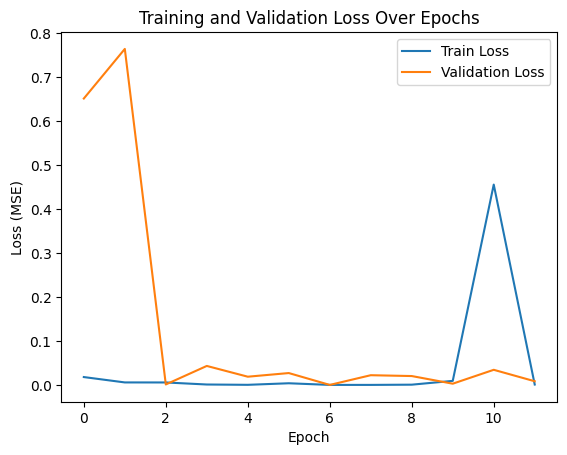

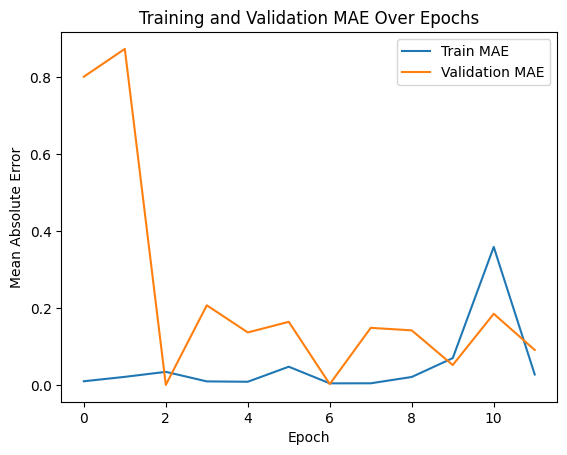

In [34]:
import matplotlib.pyplot as plt

# Plot Training & Validation Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

# Plot Training & Validation MAE
plt.figure()
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.title('Training and Validation MAE Over Epochs')
plt.legend()
plt.show()
